In [1]:
import xml.etree.ElementTree as ET
tree = ET.parse('fracas.xml')
root = tree.getroot()

In [2]:
import xml.etree.ElementTree as ET
import csv

tree = ET.parse("fracas.xml")
root = tree.getroot()

rows = []

current_section = ""
current_subsection = ""

for elem in root:

    # Track section
    if elem.tag == "comment" and elem.get("class") == "section":
        current_section = elem.text.strip()

    # Track subsection
    elif elem.tag == "comment" and elem.get("class") == "subsection":
        current_subsection = elem.text.strip()

    # Extract problem data
    elif elem.tag == "problem":
        problem_id = elem.get("id", "").strip()
        fracas_answer = elem.get("fracas_answer", "").strip()
        fracas_nonstandard = elem.get("fracas_nonstandard", "").strip()

        # collect all <p> texts
        p_texts = [p.text.strip() for p in elem.findall("p") if p.text]
        p_combined = " ".join(p_texts)

        # flag: 1 if multiple p's, 0 if only one
        multiple_p = 1 if len(p_texts) > 1 else 0

        num_p = len(p_texts)

        h = elem.findtext("h", default="").strip()
        a = elem.findtext("a", default="").strip()

        rows.append([
            current_section,
            current_subsection,
            problem_id,
            fracas_answer,
            fracas_nonstandard,
            multiple_p,
            num_p,
            p_combined,
            h,
            a
        ])

# Write CSV
with open("fracas_temp.csv", "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow([
        "section",
        "subsection",
        "problem_id",
        "fracas_answer",
        "fracas_nonstandard",
        "multiple_p",
        "num_p",
        "p",
        "h",
        "a"
    ])
    writer.writerows(rows)

print("CSV created successfully.")

CSV created successfully.


In [3]:
import pandas as pd

df = pd.read_csv('fracas_temp.csv')

# Number of rows per section
rows_per_section = df.groupby('section').size().rename('num_rows')

# Number of unique subsections per section
subsections_per_section = df.groupby('section')['subsection'].nunique().rename('num_subsections')

# Mode of num_p per section
mode_per_section = df.groupby('section')['num_p'].agg(lambda x: x.mode().iloc[0]).rename('mode_num_p')

# Combine into one summary table
summary = pd.concat([rows_per_section, subsections_per_section, mode_per_section], axis=1)

# --- Totals for the whole dataset ---
total_rows = len(df)
total_subsections = df['subsection'].nunique()
total_mode_num_p = df['num_p'].mode().iloc[0]

summary.loc['TOTAL'] = [total_rows, total_subsections, total_mode_num_p]

# --- Format num_rows as "count (percentage%)" ---
summary['num_rows'] = summary['num_rows'].apply(
    lambda x: f"{x} ({x / total_rows * 100:.1f}%)"
)

print(summary)

                               num_rows  num_subsections  mode_num_p
section                                                             
1 GENERALIZED QUANTIFIERS    80 (23.1%)                5           1
2 PLURALS                     33 (9.5%)                6           1
3 (NOMINAL) ANAPHORA          28 (8.1%)                6           2
4 ELLIPSIS                   55 (15.9%)                9           2
5 ADJECTIVES                  23 (6.6%)                6           1
6 COMPARATIVES                31 (9.0%)                6           1
7 TEMPORAL REFERENCE         75 (21.7%)                5           1
8 VERBS                        8 (2.3%)                2           1
9 ATTITUDES                   13 (3.8%)                2           1
TOTAL                      346 (100.0%)               47           1


In [4]:
# exclude_ids = {1, 59, 107, 108, 172, 191, 193, 195, 216, 229, 230, 233, 236, 237, 239, 244, 245, 249, 250, 307, 315, 320, 322, 324}
exclude_ids = {1, 107, 108, 172, 216, 229, 230, 233, 236, 237, 239, 244, 245, 249, 250, 307, 320, 322, 324}

subset = df[
    (df['multiple_p'] == 0) &
    (df['fracas_answer'].isin(['yes', 'no'])) &
    (~df['problem_id'].isin(exclude_ids))
]

print(subset.shape)
subset.head()

(104, 10)


,section,subsection,problem_id,fracas_answer,fracas_nonstandard,multiple_p,num_p,p,h,a
4,1 GENERALIZED QUANTIFIERS,1.1 Conservativity,5,yes,NaN,0,1,The really ambitious tenors are Italian.,There are really ambitious tenors who are Ital...,Yes
5,1 GENERALIZED QUANTIFIERS,1.1 Conservativity,6,no,NaN,0,1,No really great tenors are modest.,There are really great tenors who are modest.,No
6,1 GENERALIZED QUANTIFIERS,1.1 Conservativity,7,yes,NaN,0,1,Some great tenors are Swedish.,There are great tenors who are Swedish.,Yes
7,1 GENERALIZED QUANTIFIERS,1.1 Conservativity,8,yes,NaN,0,1,Many great tenors are German.,There are great tenors who are German.,Yes
8,1 GENERALIZED QUANTIFIERS,1.1 Conservativity,9,yes,NaN,0,1,Several great tenors are British.,There are great tenors who are British.,Yes


In [5]:
# Number of rows per section
rows_per_section_subset = subset.groupby('section').size().rename('num_rows')

# Number of unique subsections per section
subsections_per_section_subset = subset.groupby('section')['subsection'].nunique().rename('num_subsections')


# Combine into one summary_subset table
summary_subset = pd.concat([rows_per_section_subset, subsections_per_section_subset], axis=1)

# --- Totals for the whole dataset ---
total_rows_subset = len(subset)
total_subsections_subset = subset['subsection'].nunique()

summary_subset.loc['TOTAL'] = [total_rows_subset, total_subsections_subset]

# --- Format num_rows as "count (percentage%)" ---
summary_subset['num_rows'] = summary_subset['num_rows'].apply(
    lambda x: f"{x} ({x / total_rows_subset * 100:.1f}%)"
)

print(summary_subset)

                               num_rows  num_subsections
section                                                 
1 GENERALIZED QUANTIFIERS    23 (22.1%)                5
2 PLURALS                    17 (16.3%)                4
3 (NOMINAL) ANAPHORA           5 (4.8%)                2
4 ELLIPSIS                   18 (17.3%)                4
5 ADJECTIVES                   8 (7.7%)                4
7 TEMPORAL REFERENCE         20 (19.2%)                3
8 VERBS                        6 (5.8%)                2
9 ATTITUDES                    7 (6.7%)                2
TOTAL                      104 (100.0%)               26


In [8]:
# Number of rows per section (full dataset, needed for the second percentage)
rows_per_section = df.groupby('section').size().rename('num_rows_full')

# Number of rows per section (subset)
rows_per_section_subset = subset.groupby('section').size().rename('num_rows')

# Number of unique subsections per section (subset)
subsections_per_section_subset = subset.groupby('section')['subsection'].nunique().rename('num_subsections')

# --- Combine into one summary_subset table ---
summary_subset = pd.concat([rows_per_section_subset, subsections_per_section_subset, rows_per_section], axis=1)

# --- Totals ---
total_rows_subset = len(subset)
total_subsections_subset = subset['subsection'].nunique()
total_rows_full = len(df)

summary_subset.loc['TOTAL'] = [total_rows_subset, total_subsections_subset, total_rows_full]

# --- New column: % of subset rows relative to total subset rows ---
summary_subset['pct_of_subset'] = summary_subset['num_rows'].apply(
    lambda x: f"{x / total_rows_subset * 100:.1f}%"
)

# --- New column: % of subset rows relative to that section's rows in the full dataset ---
summary_subset['pct_of_full_section'] = (
    summary_subset['num_rows'] / summary_subset['num_rows_full'] * 100
).apply(lambda x: f"{x:.1f}%")

# Drop the helper column if you don't want the raw full-dataset count cluttering the table
summary_subset = summary_subset.drop(columns='num_rows_full')

print(summary_subset)

                           num_rows  num_subsections pct_of_subset  \
section                                                              
1 GENERALIZED QUANTIFIERS      23.0              5.0         22.1%   
2 PLURALS                      17.0              4.0         16.3%   
3 (NOMINAL) ANAPHORA            5.0              2.0          4.8%   
4 ELLIPSIS                     18.0              4.0         17.3%   
5 ADJECTIVES                    8.0              4.0          7.7%   
7 TEMPORAL REFERENCE           20.0              3.0         19.2%   
8 VERBS                         6.0              2.0          5.8%   
9 ATTITUDES                     7.0              2.0          6.7%   
6 COMPARATIVES                  NaN              NaN          nan%   
TOTAL                         104.0             26.0        100.0%   

                          pct_of_full_section  
section                                        
1 GENERALIZED QUANTIFIERS               28.7%  
2 PLURALS      

In [9]:
# Number of rows per section (full dataset, needed for percentages)
rows_per_section = df.groupby('section').size().rename('num_rows_full')

# Number of unique subsections per section (full dataset, needed for the new percentage)
subsections_per_section_full = df.groupby('section')['subsection'].nunique().rename('num_subsections_full')

# Number of rows per section (subset)
rows_per_section_subset = subset.groupby('section').size().rename('num_rows')

# Number of unique subsections per section (subset)
subsections_per_section_subset = subset.groupby('section')['subsection'].nunique().rename('num_subsections')

# --- Combine into one summary_subset table ---
summary_subset = pd.concat(
    [rows_per_section_subset, subsections_per_section_subset, rows_per_section, subsections_per_section_full],
    axis=1
)

# --- Totals ---
total_rows_subset = len(subset)
total_subsections_subset = subset['subsection'].nunique()
total_rows_full = len(df)
total_subsections_full = df['subsection'].nunique()

summary_subset.loc['TOTAL'] = [total_rows_subset, total_subsections_subset, total_rows_full, total_subsections_full]

# --- % of subset rows relative to total subset rows ---
summary_subset['pct_of_subset'] = summary_subset['num_rows'].apply(
    lambda x: f"{x / total_rows_subset * 100:.1f}%"
)

# --- % of subset rows relative to that section's rows in the full dataset ---
summary_subset['pct_of_full_section'] = (
    summary_subset['num_rows'] / summary_subset['num_rows_full'] * 100
).apply(lambda x: f"{x:.1f}%")

# --- % of subset subsections relative to that section's subsections in the full dataset ---
summary_subset['pct_subsections_retained'] = (
    summary_subset['num_subsections'] / summary_subset['num_subsections_full'] * 100
).apply(lambda x: f"{x:.1f}%")

# Drop helper columns if you don't want raw full-dataset counts cluttering the table
summary_subset = summary_subset.drop(columns=['num_rows_full', 'num_subsections_full'])

print(summary_subset)

                           num_rows  num_subsections pct_of_subset  \
section                                                              
1 GENERALIZED QUANTIFIERS      23.0              5.0         22.1%   
2 PLURALS                      17.0              4.0         16.3%   
3 (NOMINAL) ANAPHORA            5.0              2.0          4.8%   
4 ELLIPSIS                     18.0              4.0         17.3%   
5 ADJECTIVES                    8.0              4.0          7.7%   
7 TEMPORAL REFERENCE           20.0              3.0         19.2%   
8 VERBS                         6.0              2.0          5.8%   
9 ATTITUDES                     7.0              2.0          6.7%   
6 COMPARATIVES                  NaN              NaN          nan%   
TOTAL                         104.0             26.0        100.0%   

                          pct_of_full_section pct_subsections_retained  
section                                                                 
1 GENERALIZED

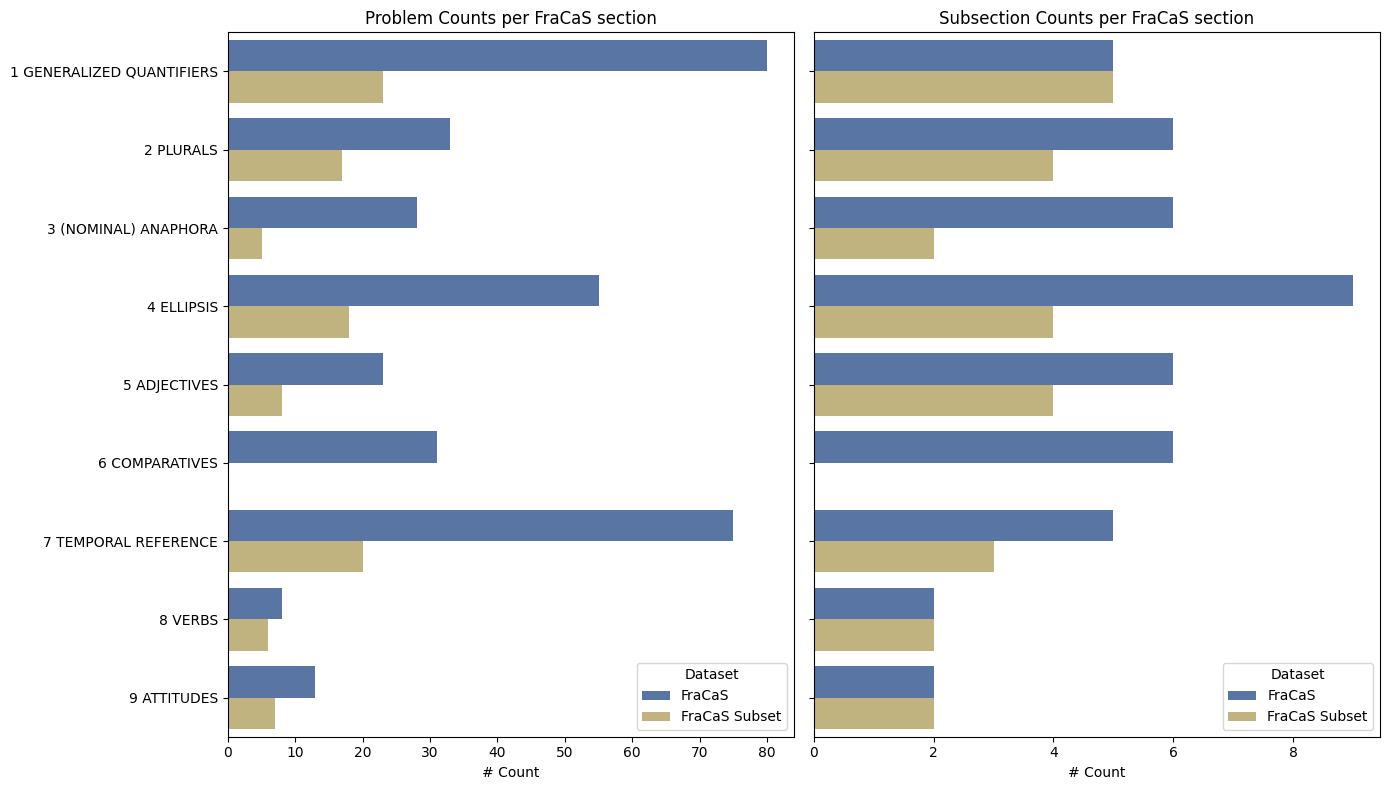

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

palette_full = sns.color_palette("deep")

# First plot gets colors 0 and 1, second plot gets colors 2 and 3
palette_plot1 = [palette_full[0], palette_full[8]]
palette_plot2 = [palette_full[0], palette_full[8]]

# --- Recompute full-dataset stats (numeric) ---
rows_per_section = df.groupby('section').size().rename('num_rows')
subsections_per_section = df.groupby('section')['subsection'].nunique().rename('num_subsections')

# --- Recompute subset stats (numeric) ---
rows_per_section_subset = subset.groupby('section').size().rename('num_rows')
subsections_per_section_subset = subset.groupby('section')['subsection'].nunique().rename('num_subsections')

# --- Combine into comparison dataframes ---
rows_compare = pd.concat(
    [rows_per_section.rename('FraCaS'), rows_per_section_subset.rename('FraCaS Subset')],
    axis=1
).fillna(0).reset_index()

subsections_compare = pd.concat(
    [subsections_per_section.rename('FraCaS'), subsections_per_section_subset.rename('FraCaS Subset')],
    axis=1
).fillna(0).reset_index()

# --- Enforce consistent section order across both plots ---
section_order = rows_compare['section'].tolist()

# --- Melt to long format for seaborn ---
rows_long = rows_compare.melt(id_vars='section', var_name='Dataset', value_name='num_rows')
subsections_long = subsections_compare.melt(id_vars='section', var_name='Dataset', value_name='num_subsections')

# --- One figure, two columns, shared y-axis ---
fig, axes = plt.subplots(1, 2, figsize=(14, 8), sharey=True)

sns.barplot(data=rows_long, y='section', x='num_rows', hue='Dataset',
            order=section_order, palette=palette_plot1, ax=axes[0])
axes[0].set_title('Problem Counts per FraCaS section')
axes[0].set_xlabel('# Count')
axes[0].set_ylabel('')
axes[0].legend(title='Dataset', loc='lower right')

sns.barplot(data=subsections_long, y='section', x='num_subsections', hue='Dataset',
            order=section_order, palette=palette_plot2, ax=axes[1])
axes[1].set_title('Subsection Counts per FraCaS section')
axes[1].set_xlabel('# Count')
axes[1].set_ylabel('')
axes[1].tick_params(axis='y', labelleft=False)  # avoid duplicate labels on the right plot
axes[1].legend(title='Dataset', loc='lower right')

plt.tight_layout()
plt.savefig('subset_comparison.pdf', bbox_inches='tight')
plt.show()